In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
data = pd.read_csv('train.csv')
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T #flip it so each column is an example instead of each row.
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T 
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [4]:
#initial param

def init_params():
    W1 = np.random.rand(10, 784) - 0.5 #rand dist. between 0 and 1
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1,W2, b2

#forward prompagation
def ReLU(Z):
    #ReLU 
    # x if x > 0
    # 0 if x <= 0
    return np.maximum(Z, 0) #goes throught all elements in Z, if one of them is greater than 0 returns Z, if not returns 0

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z)) #preserves amount of columns, but collapses rows to just 1, to have output of the range needed
    return A 

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    #dot product between weight and input layer + bias
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

#Backward prompagation
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def deriv_ReLU(Z):
    return Z > 0 # derivative of the slope is 0 or 1, and same with booleans

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [5]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [6]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[8 6 6 ... 2 2 6] [2 7 6 ... 9 7 6]
0.1294390243902439
Iteration:  10
[8 7 6 ... 2 2 6] [2 7 6 ... 9 7 6]
0.20692682926829267
Iteration:  20
[8 7 6 ... 2 8 6] [2 7 6 ... 9 7 6]
0.27082926829268295
Iteration:  30
[3 7 6 ... 2 1 6] [2 7 6 ... 9 7 6]
0.32482926829268294
Iteration:  40
[3 7 6 ... 2 1 6] [2 7 6 ... 9 7 6]
0.3681951219512195
Iteration:  50
[3 7 6 ... 2 7 6] [2 7 6 ... 9 7 6]
0.3996829268292683
Iteration:  60
[3 7 6 ... 2 7 6] [2 7 6 ... 9 7 6]
0.43165853658536585
Iteration:  70
[3 7 6 ... 2 7 6] [2 7 6 ... 9 7 6]
0.4578048780487805
Iteration:  80
[3 7 6 ... 2 7 6] [2 7 6 ... 9 7 6]
0.48241463414634145
Iteration:  90
[3 7 6 ... 2 7 6] [2 7 6 ... 9 7 6]
0.5093414634146342
Iteration:  100
[3 7 6 ... 2 7 6] [2 7 6 ... 9 7 6]
0.5353414634146342
Iteration:  110
[3 7 6 ... 2 7 6] [2 7 6 ... 9 7 6]
0.5600243902439025
Iteration:  120
[3 7 6 ... 2 7 6] [2 7 6 ... 9 7 6]
0.5859268292682926
Iteration:  130
[3 7 6 ... 2 7 6] [2 7 6 ... 9 7 6]
0.6087560975609756
Iteration:  

In [7]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

In [12]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[2 3 1 2 8 3 4 1 3 8 1 9 1 2 6 6 6 2 1 2 9 6 3 3 9 8 7 0 9 5 2 1 3 5 8 6 5
 6 0 8 7 1 3 1 5 4 1 4 7 0 1 5 8 1 1 6 0 7 4 6 9 4 7 2 3 2 0 4 7 5 8 2 9 1
 7 4 6 9 2 1 3 0 2 2 6 1 0 4 9 7 4 3 4 8 1 8 9 6 2 0 9 8 8 2 3 8 8 9 0 3 3
 8 9 4 8 6 9 2 1 2 2 5 9 4 4 9 3 1 7 0 2 9 5 7 4 1 4 4 1 9 7 7 2 9 1 0 3 4
 9 5 7 5 2 8 3 0 2 2 0 5 7 3 7 8 7 8 3 9 8 4 7 4 1 2 2 6 8 1 3 0 8 1 4 0 7
 1 0 3 2 4 3 4 8 4 9 6 8 9 0 3 0 9 1 7 0 0 8 3 1 7 1 0 0 0 2 9 9 9 2 6 0 7
 9 5 4 8 8 1 5 9 8 3 3 8 8 9 2 1 4 7 7 9 5 8 2 5 2 6 2 2 4 6 4 9 2 6 7 9 9
 8 2 1 2 5 5 7 8 2 9 0 1 7 3 0 2 4 6 0 3 9 0 7 0 4 4 4 4 6 5 6 8 2 2 2 1 8
 0 9 0 2 2 8 5 0 5 3 3 0 9 3 2 5 9 1 5 2 7 2 6 0 6 3 9 0 0 9 9 7 2 9 6 0 1
 0 2 4 6 9 0 0 2 3 2 6 8 5 9 1 7 2 6 7 8 6 3 6 1 6 9 4 1 6 5 0 6 1 3 8 1 1
 2 3 6 0 5 1 9 2 2 3 1 6 6 6 3 9 8 7 2 1 9 0 9 4 1 6 4 8 0 2 6 8 6 9 0 7 4
 5 0 2 3 8 7 4 2 9 5 6 7 4 5 0 4 6 0 8 0 2 6 6 1 1 9 7 9 2 2 1 5 9 5 7 9 0
 1 6 9 4 1 2 1 8 1 8 8 5 6 3 8 1 9 4 1 1 0 5 1 6 5 5 1 8 2 7 9 5 1 0 3 9 0
 4 5 6 0 5 9 5 1 1 3 2 4 

0.836

Prediction:  [9]
Label:  9


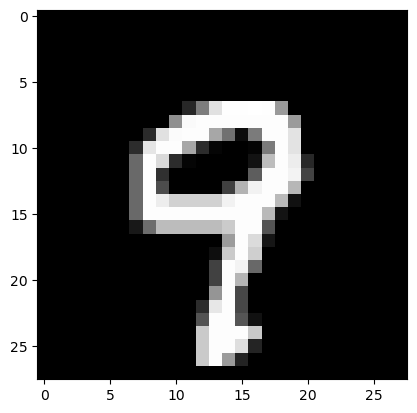

In [11]:
test_prediction(106, W1, b1, W2, b2)